In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap="gray", size=(5,5)):
    plt.figure(figsize=size)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

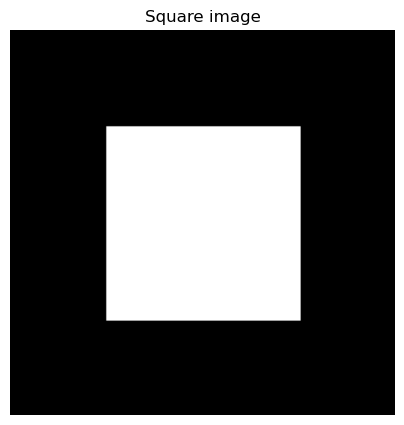

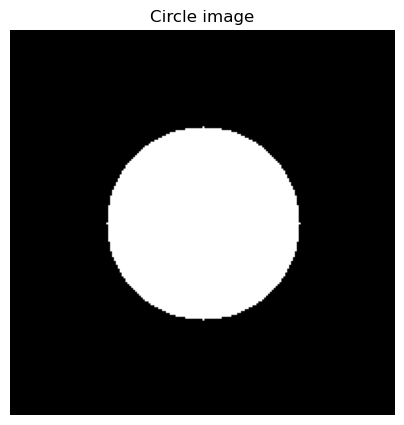

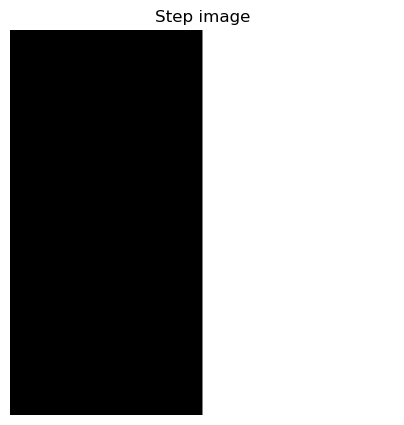

In [3]:
# Black background
img_square = np.zeros((200, 200), dtype=np.uint8)
img_circle = np.zeros((200, 200), dtype=np.uint8)
img_step = np.zeros((200, 200), dtype=np.uint8)

# Draw shapes
cv2.rectangle(img_square, (50, 50), (150, 150), 255, -1)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

# Create a step image: left side dark, right side bright
img_step[:, :100] = 50
img_step[:, 100:] = 220

show(img_square, "Square image")
show(img_circle, "Circle image")
show(img_step, "Step image")

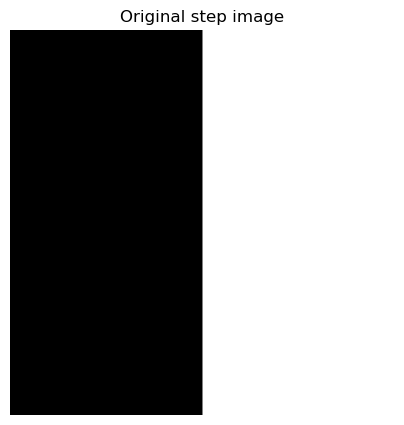

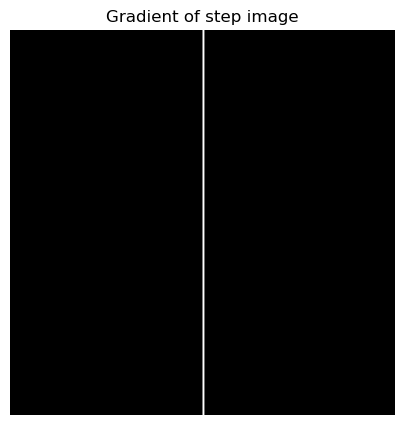

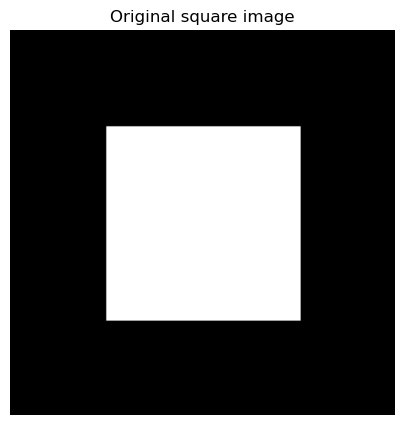

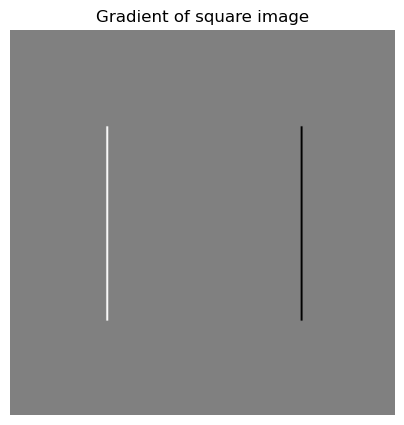

In [4]:
# Simple horizontal gradient kernel
kernel_x = np.array([[-1, 1]], dtype=np.float32)

grad_step = cv2.filter2D(img_step, cv2.CV_64F, kernel_x)
grad_square = cv2.filter2D(img_square, cv2.CV_64F, kernel_x)

show(img_step, "Original step image")
show(grad_step, "Gradient of step image")
show(img_square, "Original square image")
show(grad_square, "Gradient of square image")

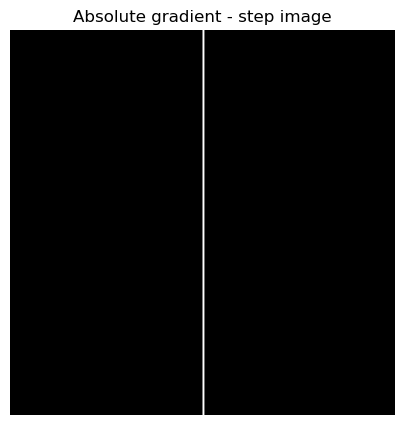

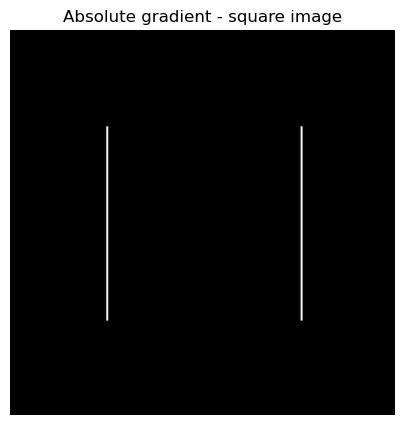

In [5]:
# Convert the gradient to absolute values for easier display
grad_square_abs = np.abs(grad_square).astype(np.uint8)
grad_step_abs = np.abs(grad_step).astype(np.uint8)

show(grad_step_abs, "Absolute gradient - step image")
show(grad_square_abs, "Absolute gradient - square image")

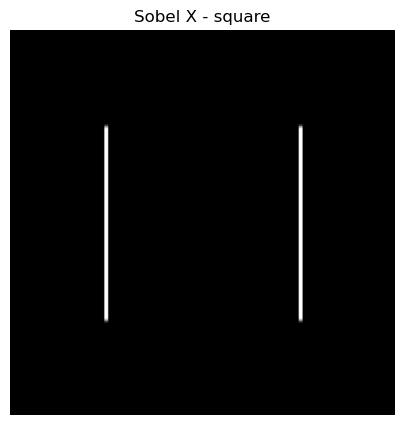

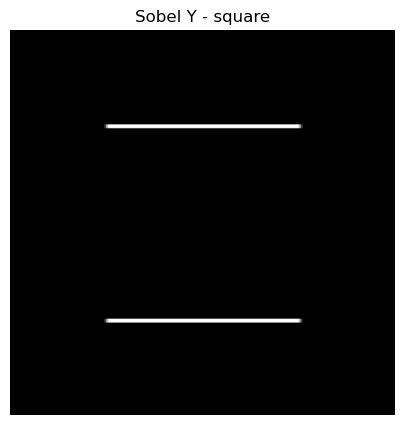

In [6]:
# Sobel in x and y directions
sobel_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)

show(np.abs(sobel_x), "Sobel X - square")
show(np.abs(sobel_y), "Sobel Y - square")

In [13]:
#TASk 1

img_square = np.zeros((200, 200), dtype=np.uint8)

# moved square
cv2.rectangle(img_square, (20, 20), (120, 120), 255, -1)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [14]:
#Create brighter or darker squares and compare gradient strength

img_square = np.zeros((200, 200), dtype=np.uint8)

# darker square
cv2.rectangle(img_square, (50, 50), (150, 150), 120, -1)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

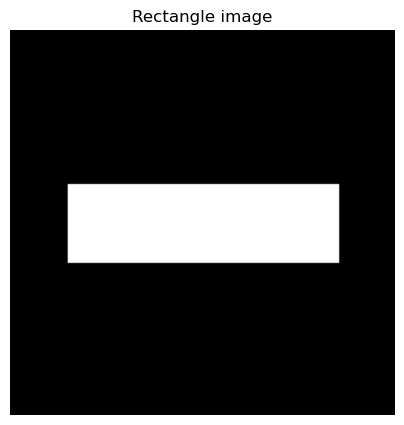

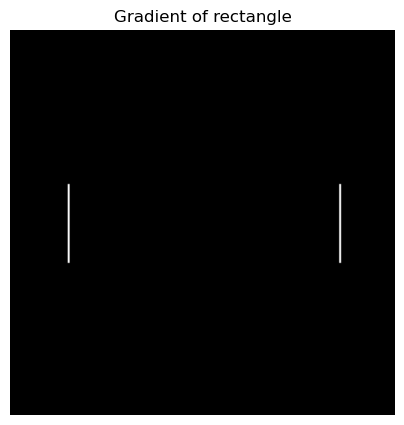

In [15]:
#Replace the square with a rectangle of different size
img_rect = np.zeros((200, 200), dtype=np.uint8)

# wide rectangle
cv2.rectangle(img_rect, (30, 80), (170, 120), 255, -1)

show(img_rect, "Rectangle image")

grad_rect = cv2.filter2D(img_rect, cv2.CV_64F, kernel_x)
grad_rect_abs = np.abs(grad_rect).astype(np.uint8)

show(grad_rect_abs, "Gradient of rectangle")

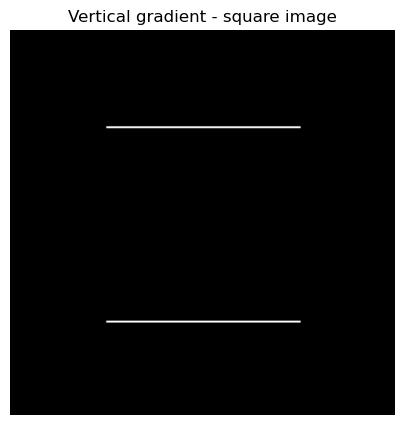

In [16]:
#intermediate task
#Apply a vertical gradient kernel

kernel_y = np.array([[-1], [1]], dtype=np.float32)

grad_square_y = cv2.filter2D(img_square, cv2.CV_64F, kernel_y)
grad_square_y_abs = np.abs(grad_square_y).astype(np.uint8)

show(grad_square_y_abs, "Vertical gradient - square image")

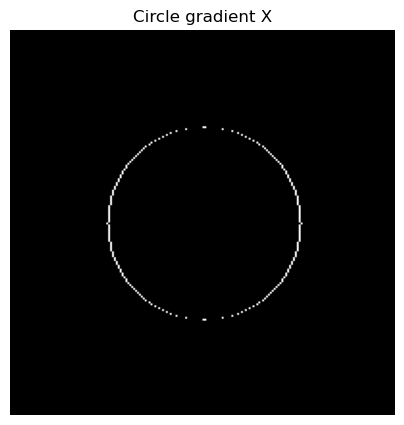

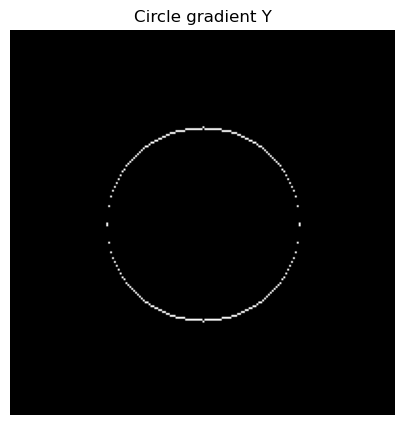

In [17]:
#Apply both kernels to the circle

grad_circle_x = cv2.filter2D(img_circle, cv2.CV_64F, kernel_x)
grad_circle_y = cv2.filter2D(img_circle, cv2.CV_64F, kernel_y)

show(np.abs(grad_circle_x).astype(np.uint8), "Circle gradient X")
show(np.abs(grad_circle_y).astype(np.uint8), "Circle gradient Y")

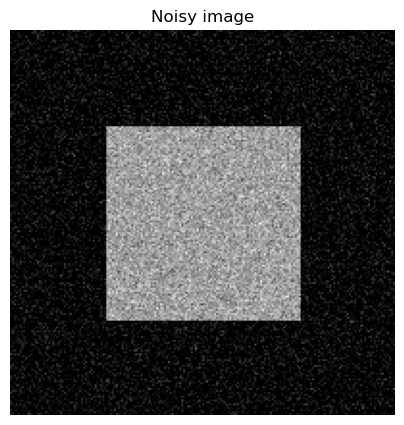

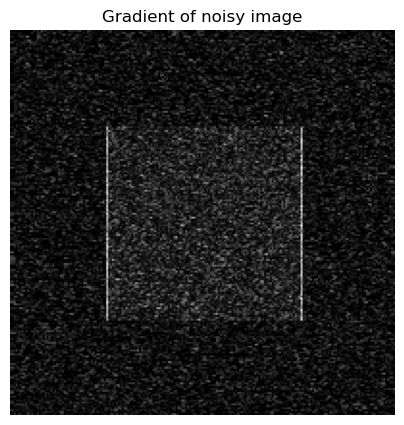

In [18]:
#Add random noise

noise = np.random.normal(0, 20, img_square.shape)
noisy_img = img_square + noise
noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

show(noisy_img, "Noisy image")

grad_noise = cv2.filter2D(noisy_img, cv2.CV_64F, kernel_x)
show(np.abs(grad_noise).astype(np.uint8), "Gradient of noisy image")

In [20]:
#Challenging Tasks
#Build a gradient function

def simple_gradient(image, direction='x'):

    if direction == 'x':
        kernel = np.array([[-1, 1]], dtype=np.float32)

    elif direction == 'y':
        kernel = np.array([[-1], [1]], dtype=np.float32)

    else:
        raise ValueError("Direction must be 'x' or 'y'")

    grad = cv2.filter2D(image, cv2.CV_64F, kernel)

    return grad


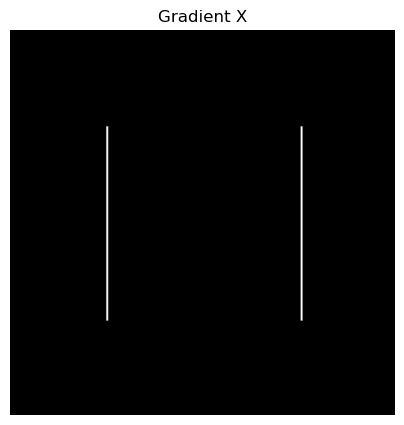

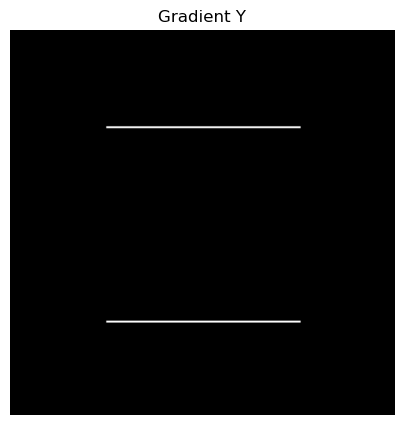

In [21]:
#usage
gx = simple_gradient(img_square, 'x')
gy = simple_gradient(img_square, 'y')

show(np.abs(gx).astype(np.uint8), "Gradient X")
show(np.abs(gy).astype(np.uint8), "Gradient Y")

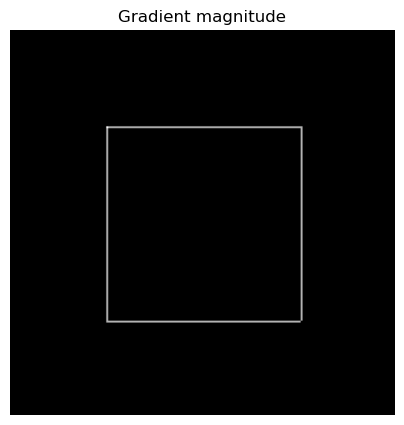

In [22]:
#Combine gradients into magnitude
gx = simple_gradient(img_square, 'x')
gy = simple_gradient(img_square, 'y')

magnitude = np.sqrt(gx**2 + gy**2)

show(magnitude, "Gradient magnitude")

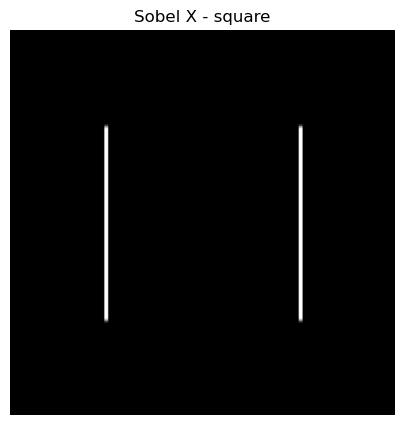

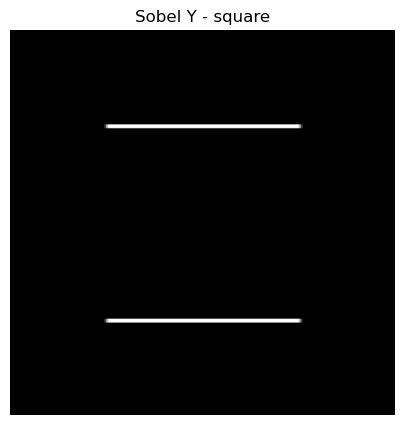

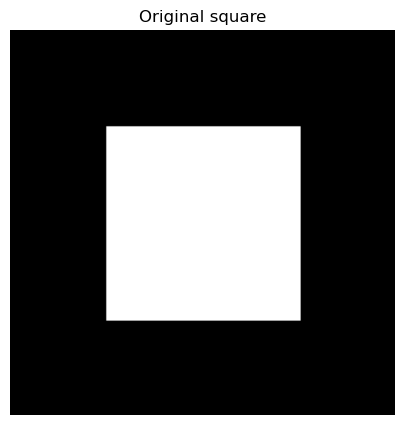

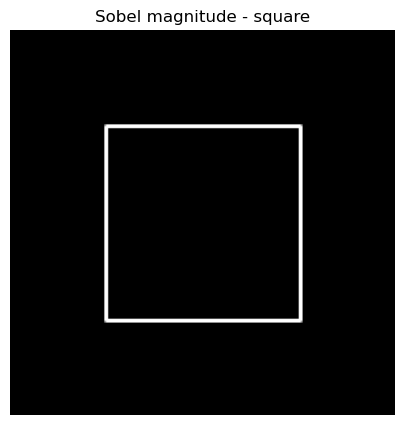

In [24]:
#TOPIC 2
# Compare Sobel with different kernel sizes
sobel_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)

show(np.abs(sobel_x), "Sobel X - square")
show(np.abs(sobel_y), "Sobel Y - square")


# Gradient magnitude from Sobel x and y
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = np.clip(sobel_mag, 0, 255).astype(np.uint8)

show(img_square, "Original square")
show(sobel_mag, "Sobel magnitude - square")

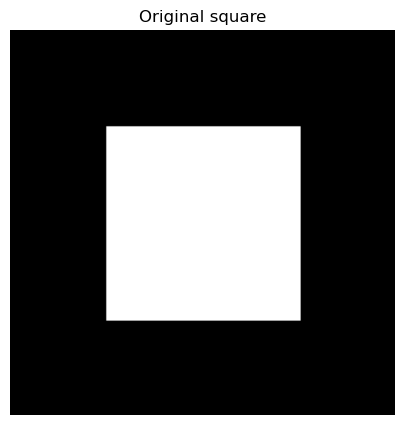

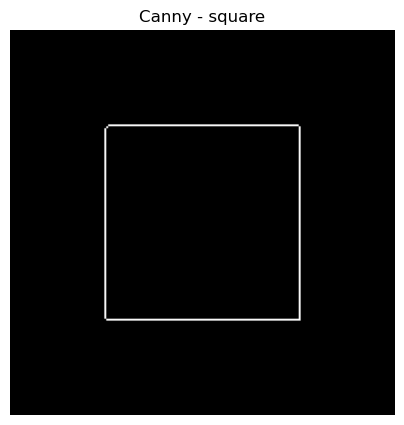

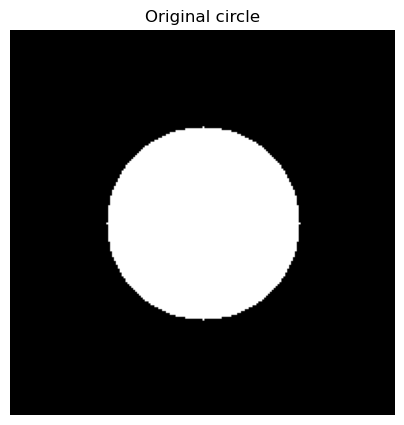

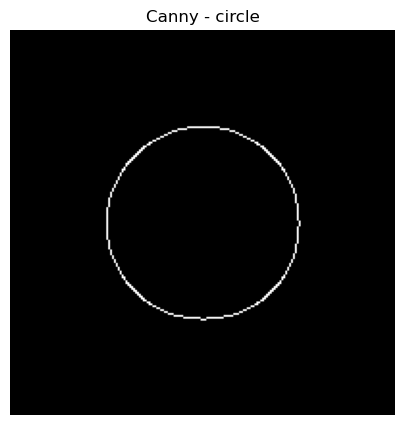

In [11]:
edges1 = cv2.Canny(img_square, 50, 150)
edges2 = cv2.Canny(img_circle, 50, 150)

show(img_square, "Original square")
show(edges1, "Canny - square")
show(img_circle, "Original circle")
show(edges2, "Canny - circle")

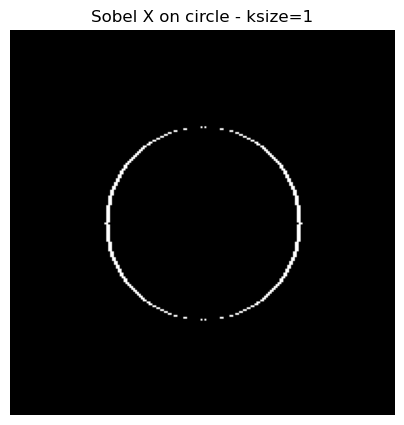

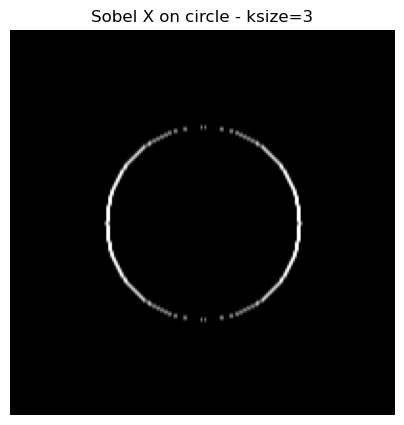

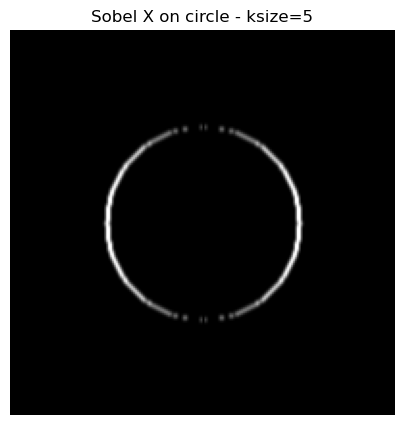

In [25]:
# Compare Sobel with different kernel sizes
for k in [1, 3, 5]:
    sobel_k = cv2.Sobel(img_circle, cv2.CV_64F, 1, 0, ksize=k)
    show(np.abs(sobel_k), f"Sobel X on circle - ksize={k}")

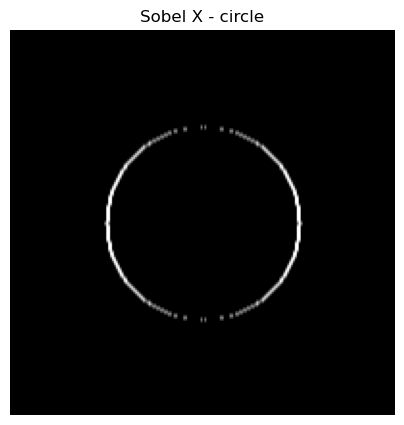

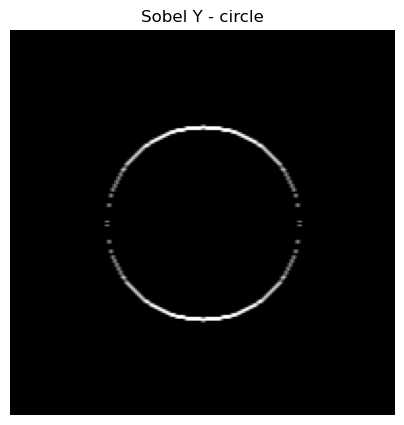

In [27]:
#Basic Tasks
#Apply Sobel X and Sobel Y to the circle image

sobel_x_circle = cv2.Sobel(img_circle, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_circle = cv2.Sobel(img_circle, cv2.CV_64F, 0, 1, ksize=3)

show(np.abs(sobel_x_circle), "Sobel X - circle")
show(np.abs(sobel_y_circle), "Sobel Y - circle")

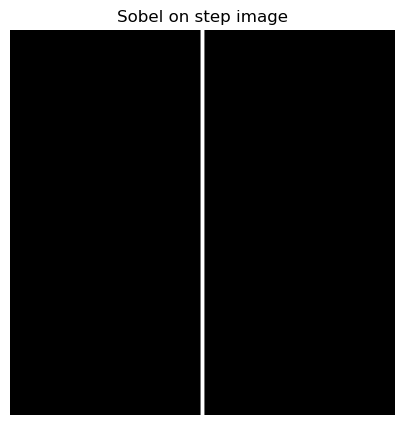

In [29]:
#Intermediate Tasks
#Apply Sobel to the step image

sobel_step = cv2.Sobel(img_step, cv2.CV_64F, 1, 0, ksize=3)
show(np.abs(sobel_step), "Sobel on step image")

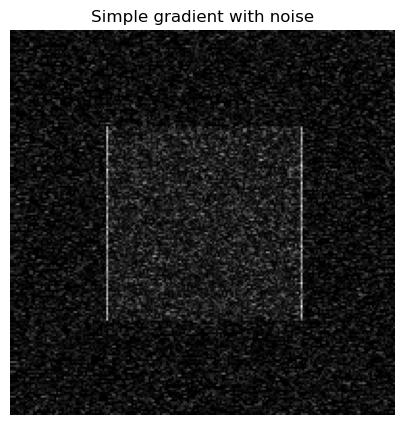

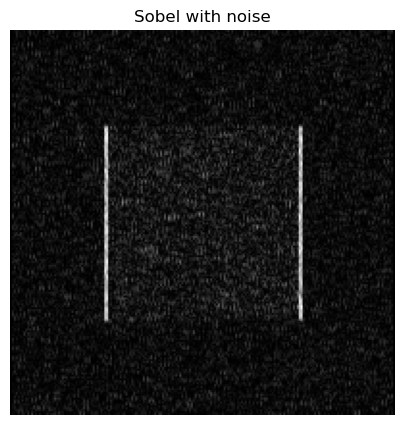

In [30]:
#Add Gaussian noise and compare

#Add noise
noise = np.random.normal(0, 20, img_square.shape)
noisy = img_square + noise
noisy = np.clip(noisy, 0, 255).astype(np.uint8)

#simple gradient
grad_simple = cv2.filter2D(noisy, cv2.CV_64F, kernel_x)
show(np.abs(grad_simple), "Simple gradient with noise")

#Sobel

sobel_noise = cv2.Sobel(noisy, cv2.CV_64F, 1, 0, ksize=3)
show(np.abs(sobel_noise), "Sobel with noise")

In [31]:
#Challenging Tasks
#Sobel function

def sobel_edges(image, ksize=3):

    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=ksize)

    magnitude = np.sqrt(gx**2 + gy**2)

    return gx, gy, magnitude

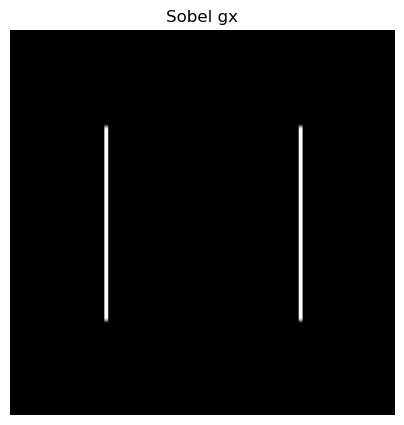

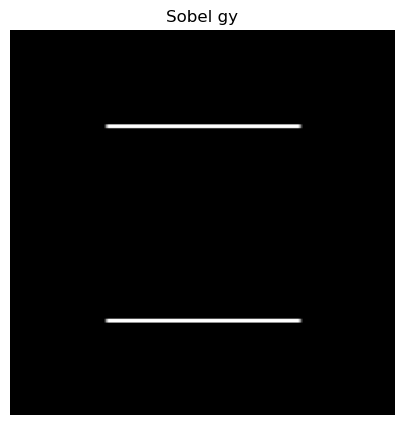

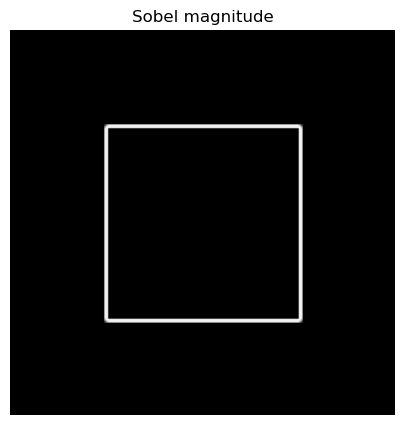

In [32]:
#usage

gx, gy, mag = sobel_edges(img_square)

show(np.abs(gx), "Sobel gx")
show(np.abs(gy), "Sobel gy")
show(mag, "Sobel magnitude")

In [33]:
#detect strong edges

# Why Sobel is preferred
# Sobel is better than a simple gradient because it:
# 1 Combines differentiation and smoothing
# 2 Reduces noise sensitivity
# 3 Produces stronger and cleaner edges
# 4 Detects edges more reliably in real images
# Therefore Sobel is commonly used in computer vision pipelines.

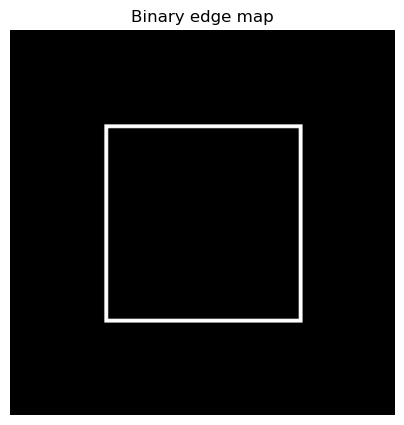

In [34]:
# Detect strong edges using threshold
binary = (sobel_mag > 80).astype(np.uint8) * 255
show(binary, "Binary edge map")

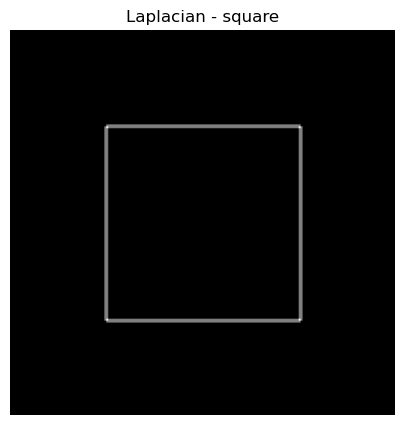

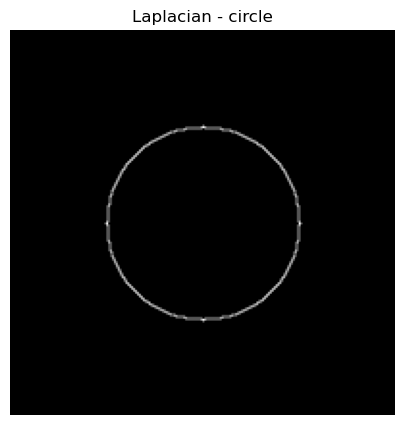

In [35]:
#topic 3 - laplacian edge detector

lap_square = cv2.Laplacian(img_square, cv2.CV_64F)
lap_circle = cv2.Laplacian(img_circle, cv2.CV_64F)

show(np.abs(lap_square), "Laplacian - square")
show(np.abs(lap_circle), "Laplacian - circle")

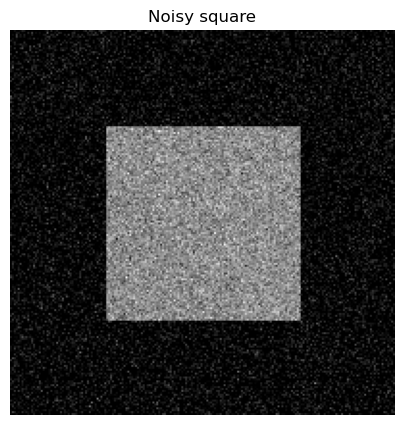

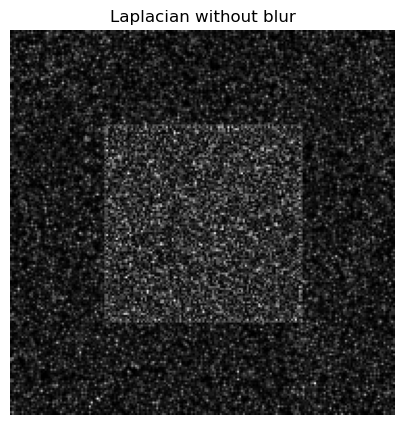

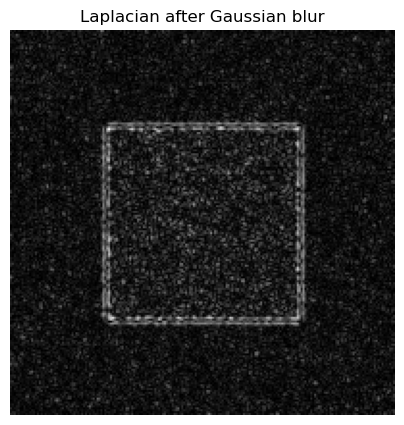

In [36]:
# Add noise to the square image
rng = np.random.default_rng(0)
noise = rng.normal(0, 25, img_square.shape)
img_square_noisy = np.clip(img_square + noise, 0, 255).astype(np.uint8)

# Laplacian without blur
lap_no_blur = cv2.Laplacian(img_square_noisy, cv2.CV_64F)

# Laplacian with Gaussian blur
img_square_blur = cv2.GaussianBlur(img_square_noisy, (5, 5), 0)
lap_blur = cv2.Laplacian(img_square_blur, cv2.CV_64F)

show(img_square_noisy, "Noisy square")
show(np.abs(lap_no_blur), "Laplacian without blur")
show(np.abs(lap_blur), "Laplacian after Gaussian blur")

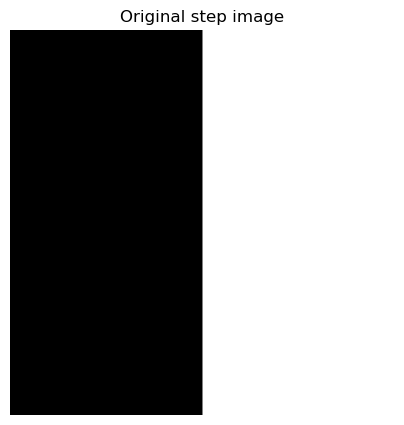

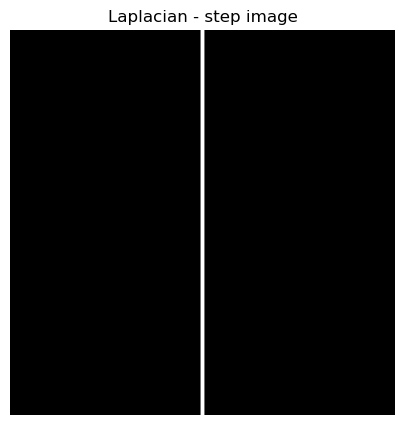

In [37]:
# Basic Tasks
# Apply Laplacian to the step image

lap_step = cv2.Laplacian(img_step, cv2.CV_64F)

show(img_step, "Original step image")
show(np.abs(lap_step), "Laplacian - step image")

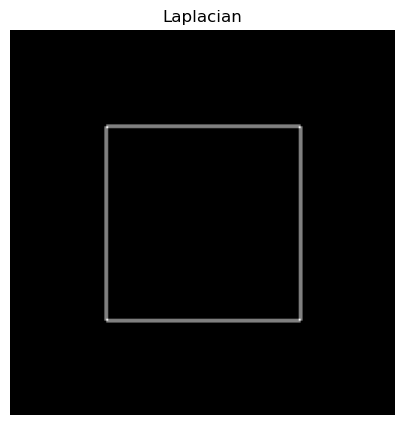

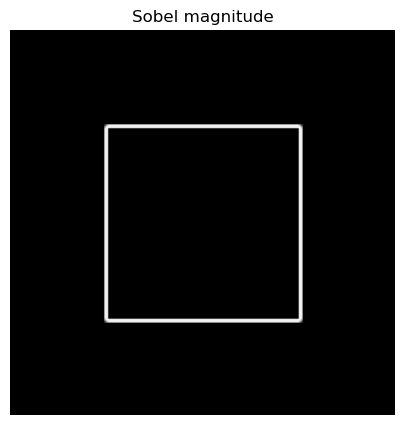

In [38]:
# Compare Laplacian with Sobel magnitude

sobel_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)

sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)

show(np.abs(lap_square), "Laplacian")
show(sobel_mag, "Sobel magnitude")

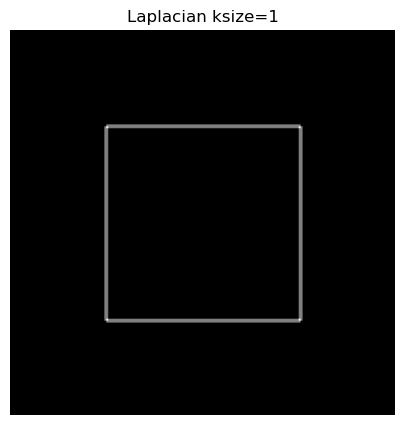

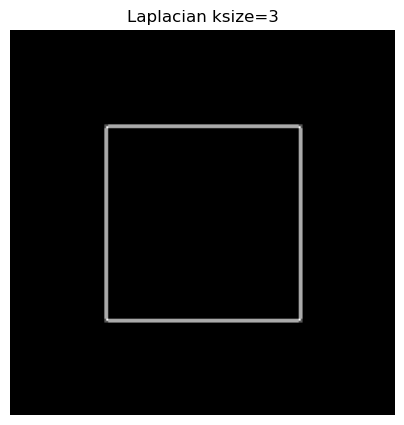

In [39]:
# Try ksize=1 and ksize=3

lap1 = cv2.Laplacian(img_square, cv2.CV_64F, ksize=1)
lap3 = cv2.Laplacian(img_square, cv2.CV_64F, ksize=3)

show(np.abs(lap1), "Laplacian ksize=1")
show(np.abs(lap3), "Laplacian ksize=3")

In [42]:
# Intermediate Tasks
# Add different noise levels

noise10 = rng.normal(0, 10, img_square.shape)
noise40 = rng.normal(0, 40, img_square.shape)

img_noise10 = np.clip(img_square + noise10, 0, 255).astype(np.uint8)
img_noise40 = np.clip(img_square + noise40, 0, 255).astype(np.uint8)

lap10 = cv2.Laplacian(img_noise10, cv2.CV_64F)
lap40 = cv2.Laplacian(img_noise40, cv2.CV_64F)


In [43]:
# Blur with different kernels

blur3 = cv2.GaussianBlur(img_square_noisy, (3,3), 0)
blur5 = cv2.GaussianBlur(img_square_noisy, (5,5), 0)
blur7 = cv2.GaussianBlur(img_square_noisy, (7,7), 0)

lap3 = cv2.Laplacian(blur3, cv2.CV_64F)
lap5 = cv2.Laplacian(blur5, cv2.CV_64F)
lap7 = cv2.Laplacian(blur7, cv2.CV_64F)

In [44]:
# Why Laplacian is more noise-sensitive than Sobel
# Reason:
# Laplacian computes second derivative
# second derivatives amplify small fluctuations
# Noise causes small intensity changes → Laplacian interprets them as edges.
# Sobel partially reduces this because:
# it uses larger smoothing weights
# it measures only the first derivative

In [45]:
# Challenging Tasks
# Count edge pixels before and after blur

threshold = 40

edges_no_blur = (np.abs(lap_no_blur) > threshold)
edges_blur = (np.abs(lap_blur) > threshold)

count_no_blur = np.sum(edges_no_blur)
count_blur = np.sum(edges_blur)

print("Edges without blur:", count_no_blur)
print("Edges with blur:", count_blur)

Edges without blur: 21861
Edges with blur: 3


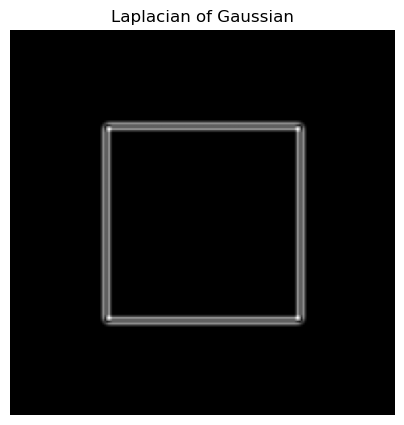

In [46]:
# Laplacian of Gaussian pipeline

blur = cv2.GaussianBlur(img_square, (5,5), 0)
log_result = cv2.Laplacian(blur, cv2.CV_64F)

show(np.abs(log_result), "Laplacian of Gaussian")

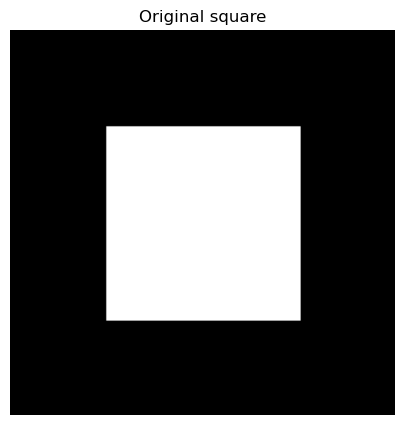

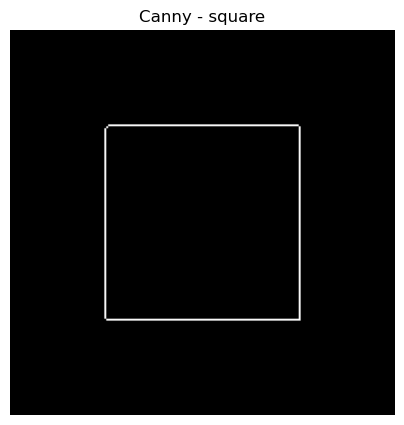

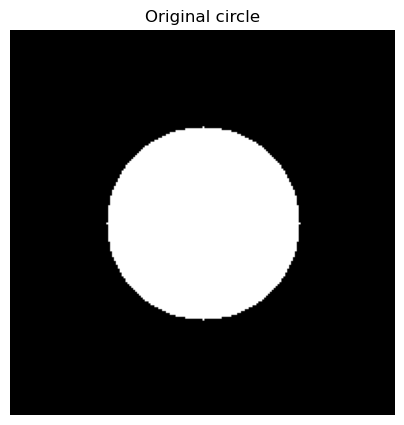

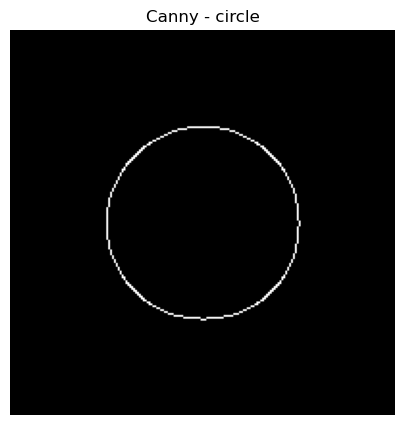

In [47]:
# ## 5. Topic 4 — Canny edge detector

edges1 = cv2.Canny(img_square, 50, 150)
edges2 = cv2.Canny(img_circle, 50, 150)

show(img_square, "Original square")
show(edges1, "Canny - square")
show(img_circle, "Original circle")
show(edges2, "Canny - circle")

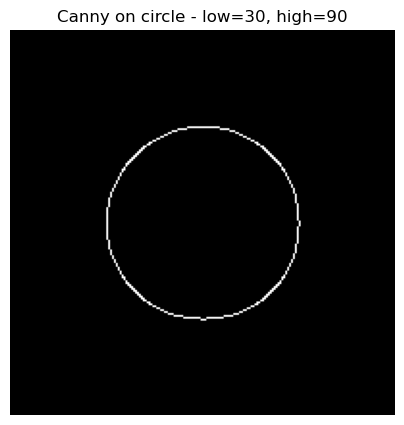

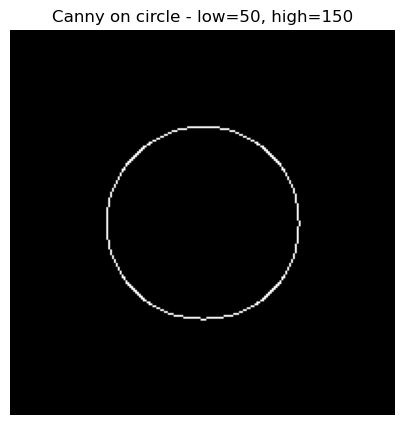

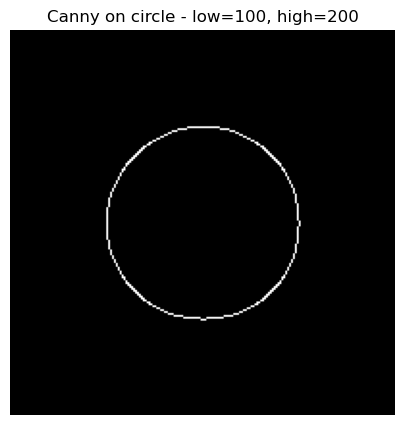

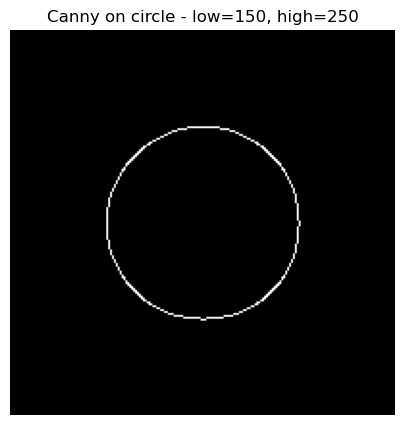

In [48]:
# Test several threshold pairs
pairs = [(30, 90), (50, 150), (100, 200), (150, 250)]

for low, high in pairs:
    edges = cv2.Canny(img_circle, low, high)
    show(edges, f"Canny on circle - low={low}, high={high}")

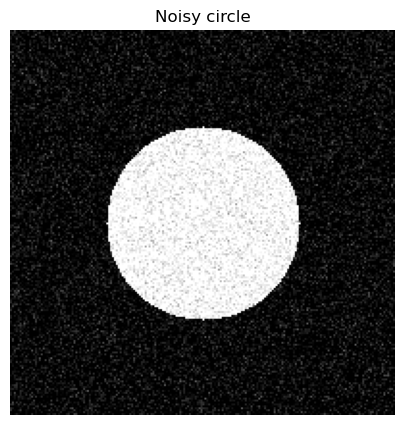

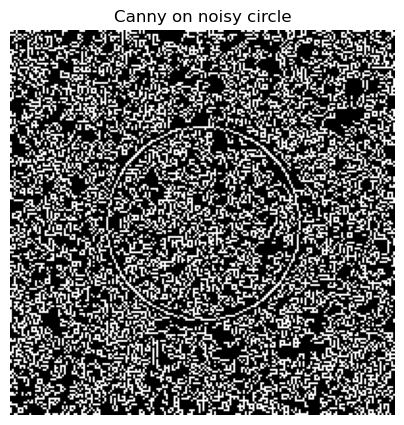

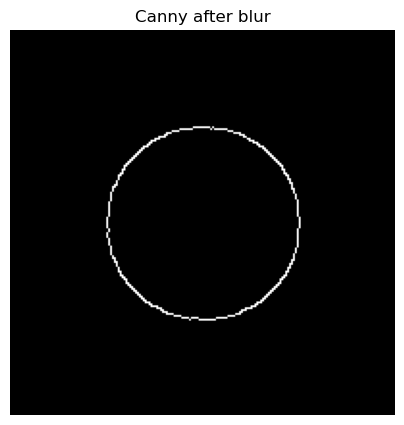

In [50]:
# Compare Canny on a noisy image
img_circle_noisy = np.clip(img_circle + rng.normal(0, 30, img_circle.shape), 0, 255).astype(np.uint8)

canny_noisy = cv2.Canny(img_circle_noisy, 50, 150)
canny_blurred = cv2.Canny(cv2.GaussianBlur(img_circle_noisy, (5, 5), 0), 50, 150)

show(img_circle_noisy, "Noisy circle")
show(canny_noisy, "Canny on noisy circle")
show(canny_blurred, "Canny after blur")

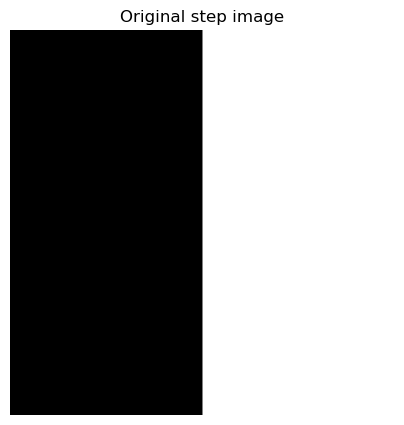

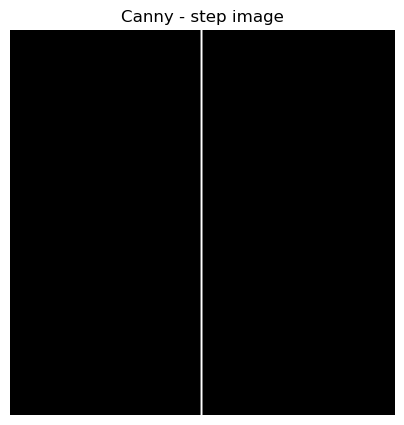

In [51]:
# Basic Tasks
# Apply Canny to the step image

edges_step = cv2.Canny(img_step, 50, 150)

show(img_step, "Original step image")
show(edges_step, "Canny - step image")

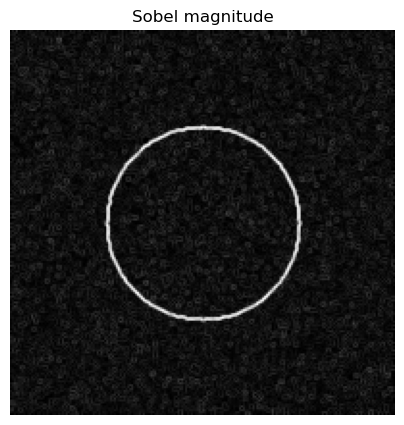

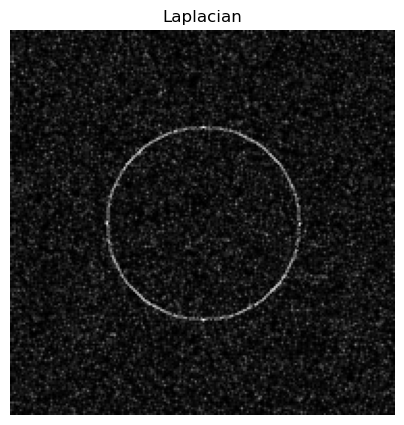

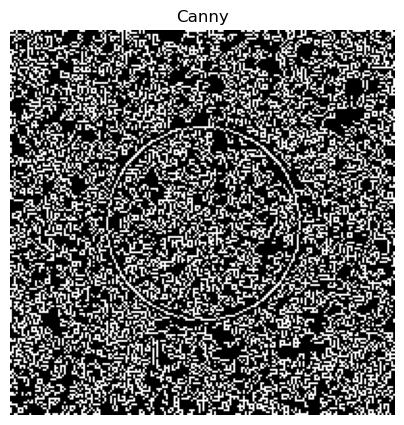

In [52]:
# Intermediate Tasks
# Compare Canny, Sobel, Laplacian on noisy image

sobel_mag = np.sqrt(
    cv2.Sobel(img_circle_noisy, cv2.CV_64F,1,0,ksize=3)**2 +
    cv2.Sobel(img_circle_noisy, cv2.CV_64F,0,1,ksize=3)**2
)

lap = cv2.Laplacian(img_circle_noisy, cv2.CV_64F)

canny = cv2.Canny(img_circle_noisy,50,150)

show(np.abs(sobel_mag),"Sobel magnitude")
show(np.abs(lap),"Laplacian")
show(canny,"Canny")

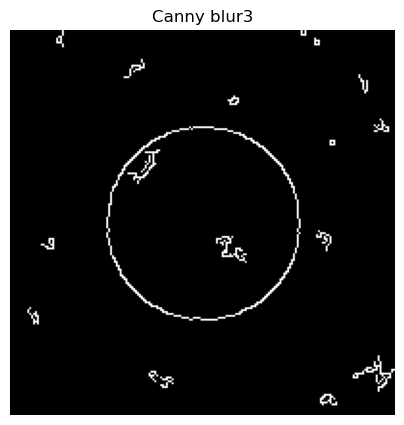

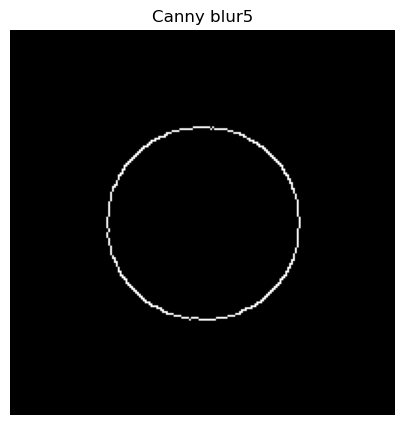

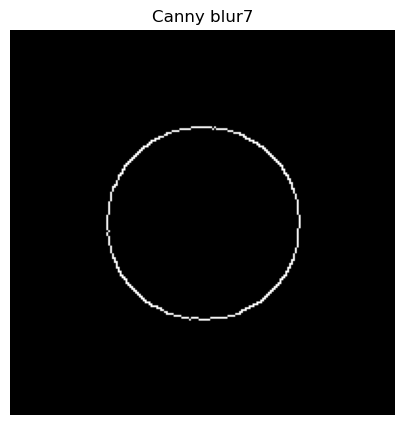

In [53]:
# Effect of Gaussian blur before Canny

blur3 = cv2.GaussianBlur(img_circle_noisy,(3,3),0)
blur5 = cv2.GaussianBlur(img_circle_noisy,(5,5),0)
blur7 = cv2.GaussianBlur(img_circle_noisy,(7,7),0)

show(cv2.Canny(blur3,50,150),"Canny blur3")
show(cv2.Canny(blur5,50,150),"Canny blur5")
show(cv2.Canny(blur7,50,150),"Canny blur7")

In [54]:
### Canny Edge Detection Experiment

| Image Type | Observation |
|-------------|-------------|
| Clean image | Edges are thin and accurate |
| Noisy image | Some false edges appear |
| Blurred image | Noise reduced, edges cleaner |

Conclusion:
Applying Gaussian blur before Canny improves edge detection in noisy images.

SyntaxError: invalid syntax (4085861148.py, line 3)

In [55]:
# Build reusable Canny function

def run_canny(image, low, high, blur=False):

    if blur:
        image = cv2.GaussianBlur(image, (5,5), 0)

    edges = cv2.Canny(image, low, high)

    return edges

In [ ]:
edges = run_canny(img_circle, 50,150, blur=True)
show(edges,"Canny result")